# Lecture 6

In [2]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib as mpl

In [4]:
unrate = pd.read_csv('UNRATE.csv', parse_dates=['observation_date'], index_col='observation_date')['UNRATE']
gdp = pd.read_csv('GDP.csv', parse_dates=['observation_date'], index_col='observation_date')['GDP']
panel = pd.read_csv('state_unemployment.csv')
panel.head()

,state,state_name,year,unrate
0,CA,California,2005,5.4
1,CA,California,2006,4.9
2,CA,California,2007,5.3
3,CA,California,2008,7.3
4,CA,California,2009,11.5


In [11]:
#time series: one state, many years
snapshot = panel[panel['state'] == 'CA']
snapshot

,state,state_name,year,unrate
0,CA,California,2005,5.4
1,CA,California,2006,4.9
2,CA,California,2007,5.3
3,CA,California,2008,7.3
4,CA,California,2009,11.5
5,CA,California,2010,12.3
6,CA,California,2011,11.7
7,CA,California,2012,10.4
8,CA,California,2013,9.0
9,CA,California,2014,7.6


In [13]:
#cross-section: six states, one year
snapshot = panel[panel['year']== 2025]
snapshot

,state,state_name,year,unrate
20,CA,California,2025,5.5
41,FL,Florida,2025,3.9
62,MI,Michigan,2025,5.1
83,NV,Nevada,2025,5.3
104,NY,New York,2025,4.3
125,TX,Texas,2025,4.2


In [6]:
#time series: one country, 944 months
unrate.tail(4)

observation_date
2026-05-01    4.3
2026-06-01    4.2
2026-07-01    4.1
2026-08-01    4.1
Name: UNRATE, dtype: float64

In [14]:
#cross-section: same year, different states
snapshot.sort_values('unrate')

,state,state_name,year,unrate
41,FL,Florida,2025,3.9
125,TX,Texas,2025,4.2
104,NY,New York,2025,4.3
62,MI,Michigan,2025,5.1
83,NV,Nevada,2025,5.3
20,CA,California,2025,5.5


In [15]:
print('mean ', round(snapshot['unrate'].mean(),2))
print('spread', round(snapshot['unrate'].max()-snapshot['unrate'].min(),1), 'points')

mean  4.72
spread 1.6 points


In [16]:
for y in [2019,2020, 2025]:
    cut = panel[panel['year'] == y]
    print(y,'| mean', round(cut['unrate'].mean(), 2),
          '| spread', round(cut['unrate'].max() - cut['unrate'].min(), 1),
           '| worst', cut.loc[cut['unrate'].idxmax(),'state'])

2019 | mean 3.82 | spread 0.9 | worst CA
2020 | mean 9.95 | spread 6.0 | worst NV
2025 | mean 4.72 | spread 1.6 | worst CA


In [17]:
#lowest unemployment
for y in [2009,2020,2025]:
    cut = panel[panel['year'] == y]
    print(y,'| mean', round(cut['unrate'].mean(), 2),
          '| spread', round(cut['unrate'].max() - cut['unrate'].min(), 1),
           '| best', cut.loc[cut['unrate'].idxmin(),'state'])

2009 | mean 10.38 | spread 5.9 | best TX
2020 | mean 9.95 | spread 6.0 | best TX
2025 | mean 4.72 | spread 1.6 | best FL


In [18]:
#Time Series
print(type(unrate.index))
print(unrate.index.dtype)
print('first', unrate.index[0].date(), '| last', unrate.index[-1].date(), '|', len(unrate), 'months')

<class 'pandas.DatetimeIndex'>
datetime64[us]
first 1948-01-01 | last 2026-08-01 | 944 months


In [ ]:
#Datetime Index slicing -> partial string indexing, aka Time Series
change = unrate.diff()
print('biggest one-month change:', change.max(), 'in', change.idxmax().strftime('%B %Y'))
print('year-earlier comparison:', (unrate-unrate.shift(

In [19]:
#Panel data: between-state differences
panel.groupby('state')['unrate'].mean().round(2).sort_values()

state
TX    5.35
FL    5.67
NY    5.90
MI    7.01
CA    7.03
NV    7.38
Name: unrate, dtype: float64

In [22]:
#Within-state averages
panel['state_mean']= panel.groupby('state')['unrate'].transform('mean')
panel['within'] = panel['unrate']-panel['state_mean']
print('total variance         ', round(panel['unrate'].var(ddof=0),2))
print('between states (means)  ', round(panel.groupby('state')['unrate'].mean().var(ddof=0),2))
print('within states (deviations)', round(panel['within'].var(ddof=0),2))

total variance          6.86
between states (means)   0.6
within states (deviations) 6.26


In [24]:
#One column per state
wide = panel.pivot(index='year', columns='state', values='unrate')
wide.tail(4)

state,CA,FL,MI,NV,NY,TX
year,,,,,,
2022,4.3,3.0,4.2,5.2,4.3,3.9
2023,4.7,2.9,3.9,5.1,4.0,4.0
2024,5.3,3.4,4.7,5.4,4.2,4.1
2025,5.5,3.9,5.1,5.3,4.3,4.2


In [25]:
d=dt.date(2020,4,1)
t=dt.datetime(2020,4,1,9,30)
print(d, '|', t)
print('a date minus a date is a timedelta:', dt.date(2020,4,1)-dt.date(2019,4,1))

2020-04-01 | 2020-04-01 09:30:00
a date minus a date is a timedelta: 366 days, 0:00:00


In [ ]:
#Testing your data and code
d

In [35]:
#Problems
#Who has the lowest unemployment now
#Extract 2025 rows from panel. Row count, key? Key = one row per state, since year is fixed
snap = panel[panel['year']==2025]
snap = snap.sort_values('unrate')
snap


,state,state_name,year,unrate,state_mean,within
41,FL,Florida,2025,3.9,5.671429,-1.771429
125,TX,Texas,2025,4.2,5.347619,-1.147619
104,NY,New York,2025,4.3,5.904762,-1.604762
62,MI,Michigan,2025,5.1,7.014286,-1.914286
83,NV,Nevada,2025,5.3,7.376190,-2.076190
20,CA,California,2025,5.5,7.033333,-1.533333


Text(0.06, 0.01, 'Source: something')

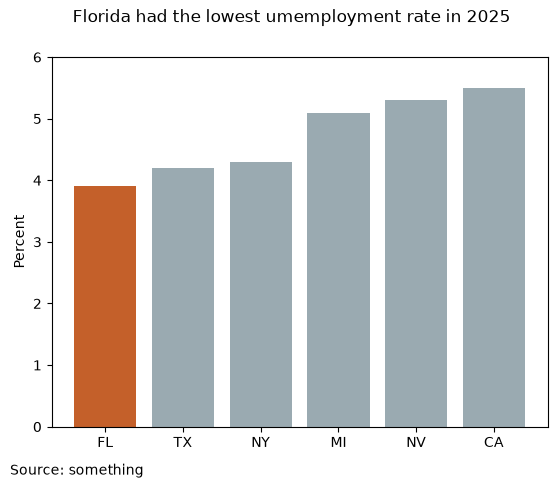

In [36]:
import matplotlib.pyplot as plt
colors = ['#C4602A'] + ['#9AAAB1'] *5
fig, ax = plt.subplots()
ax.bar(snap['state'], snap['unrate'], color=colors)
ax.set_ylim(0,6)
ax.set_ylabel('Percent')
fig.suptitle('Florida had the lowest umemployment rate in 2025')
fig.text(0.06, 0.01, 'Source: something')

In [38]:
#How extreme was 2020 unemployment issue?
#slice unemployment from 1990 on, then build annual average with resample, using complete years only through 2025
monthly = unrate.loc['1990':]

complete = unrate.loc['1990':'2025']
annual = complete.resample('YE').mean()
annual

observation_date
1990-12-31    5.616667
1991-12-31    6.850000
1992-12-31    7.491667
1993-12-31    6.908333
1994-12-31    6.100000
1995-12-31    5.591667
1996-12-31    5.408333
1997-12-31    4.941667
1998-12-31    4.500000
1999-12-31    4.216667
2000-12-31    3.966667
2001-12-31    4.741667
2002-12-31    5.783333
2003-12-31    5.991667
2004-12-31    5.541667
2005-12-31    5.083333
2006-12-31    4.608333
2007-12-31    4.616667
2008-12-31    5.800000
2009-12-31    9.283333
2010-12-31    9.608333
2011-12-31    8.933333
2012-12-31    8.075000
2013-12-31    7.358333
2014-12-31    6.158333
2015-12-31    5.275000
2016-12-31    4.875000
2017-12-31    4.358333
2018-12-31    3.891667
2019-12-31    3.675000
2020-12-31    8.100000
2021-12-31    5.350000
2022-12-31    3.650000
2023-12-31    3.625000
2024-12-31    4.025000
2025-12-31    4.263636
Freq: YE-DEC, Name: UNRATE, dtype: float64

In [42]:
monthly.tail(30)

observation_date
2024-03-01    3.9
2024-04-01    3.9
2024-05-01    3.9
2024-06-01    4.1
2024-07-01    4.2
2024-08-01    4.2
2024-09-01    4.1
2024-10-01    4.1
2024-11-01    4.2
2024-12-01    4.1
2025-01-01    4.0
2025-02-01    4.2
2025-03-01    4.2
2025-04-01    4.2
2025-05-01    4.3
2025-06-01    4.1
2025-07-01    4.3
2025-08-01    4.3
2025-09-01    4.4
2025-10-01    NaN
2025-11-01    4.5
2025-12-01    4.4
2026-01-01    4.3
2026-02-01    4.4
2026-03-01    4.3
2026-04-01    4.3
2026-05-01    4.3
2026-06-01    4.2
2026-07-01    4.1
2026-08-01    4.1
Name: UNRATE, dtype: float64

Text(-130, -12, 'Apr 2020: 14.9%')

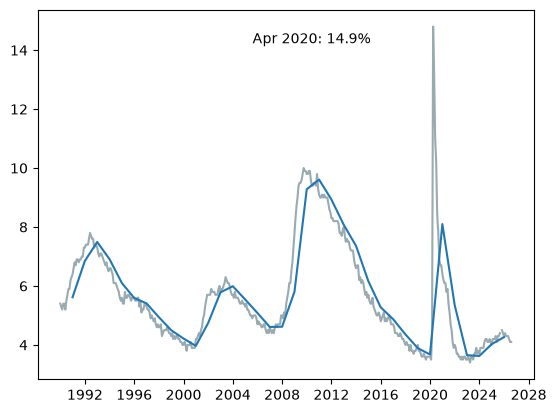

In [40]:
#Plot both on one axis (monthly in gray, annual on top)
fig, ax = plt.subplots()
ax.plot(monthly.index, monthly.values, color='#9AAAB1', label='Monthly')
ax.plot(annual.index, annual.values, label='Annual average')
ax.annotate('Apr 2020: 14.9%', xy=(unrate.idxmax(), unrate.max()), xytext=(-130, -12), textcoords='offset points')

In [44]:
print(unrate['2020'].mean())

8.1


In [45]:
 print(unrate.max(), unrate.idxmax())

14.8 2020-04-01 00:00:00
